In [1]:
import sys
sys.path.append("../src")

import torch
import torch.nn as nn
import random
import matplotlib.pyplot as plt
import os

from data import generate_examples
from model import DyckTransformer

In [2]:
det_train_data = generate_examples(50000, task="detection")
det_dev_data = generate_examples(5000, task="detection")

In [3]:
VOCAB = ["(", ")", "[", "]", "[PAD]", "[CLS]", "[SEP]"]
stoi = {tok: i for i, tok in enumerate(VOCAB)}
itos = {i: tok for tok, i in stoi.items()}

In [4]:
edit_label_vocab = ["OK", "DELETE", "INSERT())", "INSERT(])", "REPLACE())", "REPLACE(])"]
edit_stoi = {l: i for i, l in enumerate(edit_label_vocab)}

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
model = DyckTransformer(
    vocab_size=len(VOCAB),
    pad_idx=stoi["[PAD]"],
    num_edit_labels=6,
    d_model=128,
    n_heads=4,
    n_layers=2,
    max_len=80,
    dropout=0.1
)
torch.nn.init.zeros_(model.cls_head.bias)
torch.nn.init.xavier_uniform_(model.cls_head.weight)
model = model.to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

In [7]:
tiny_data = det_train_data


In [8]:

for tokens, label in tiny_data[:5]:
    print(label, tokens[:10])

0 ['[CLS]', '[', ']', '[', '(', ')', '[', '(', '(', ')']
0 ['[CLS]', '[', ']', '[', '[', '[', ']', '[', '[', ']']
0 ['[CLS]', '[', '(', '[', ']', '(', '(', ')', ']', '(']
1 ['[CLS]', '[', '(', '[', ']', '[', '(', ')', ']', '[']
1 ['[CLS]', '[', '[', '(', '(', ')', '[', ']', '[', ']']


In [9]:
batch_size = 64
train_loss_curve = []
train_acc_curve = []
dev_acc_curve = []

def accuracy(logits, y):
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()

for epoch in range(10):
    # --- training ---
    model.train()
    total_loss = 0
    total_acc = 0
    n_train_batches = 0

    for i in range(0, len(tiny_data), batch_size):
        batch = tiny_data[i:i+batch_size]
        xs, ys = zip(*batch)
        xs = torch.tensor([[stoi[t] for t in x] for x in xs]).to(device)
        ys = torch.tensor(ys).to(device)
        cls_logits, _ = model(xs)
        loss = loss_fn(cls_logits, ys)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        total_acc += accuracy(cls_logits, ys)
        n_train_batches += 1

    avg_loss = total_loss / n_train_batches
    avg_acc = total_acc / n_train_batches
    train_loss_curve.append(avg_loss)
    train_acc_curve.append(avg_acc)

    # --- dev evaluation ---
    model.eval()
    dev_acc = 0
    n_dev_batches = 0

    with torch.no_grad():
        for i in range(0, len(det_dev_data), batch_size):
            batch = det_dev_data[i:i+batch_size]
            xs, ys = zip(*batch)
            xs = torch.tensor([[stoi[t] for t in x] for x in xs]).to(device)
            ys = torch.tensor(ys).to(device)
            cls_logits, _ = model(xs)
            dev_acc += accuracy(cls_logits, ys)
            n_dev_batches += 1

    dev_acc /= n_dev_batches
    dev_acc_curve.append(dev_acc)

    print(f"epoch {epoch} | loss {avg_loss:.4f} | train acc {avg_acc:.4f} | dev acc {dev_acc:.4f}")

c:\Users\sarav\projects\dyck_transformer\.pixi\envs\default\Lib\site-packages\torch\nn\modules\transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\bld\libtorch_1772176602146\work\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


epoch 0 | loss 0.6865 | train acc 0.5447 | dev acc 0.7933
epoch 1 | loss 0.2672 | train acc 0.8915 | dev acc 0.8981
epoch 2 | loss 0.1565 | train acc 0.9439 | dev acc 0.9767
epoch 3 | loss 0.0806 | train acc 0.9726 | dev acc 1.0000
epoch 4 | loss 0.0539 | train acc 0.9824 | dev acc 1.0000
epoch 5 | loss 0.0384 | train acc 0.9888 | dev acc 0.9998
epoch 6 | loss 0.0305 | train acc 0.9915 | dev acc 1.0000
epoch 7 | loss 0.0237 | train acc 0.9935 | dev acc 1.0000
epoch 8 | loss 0.0205 | train acc 0.9944 | dev acc 1.0000
epoch 9 | loss 0.0203 | train acc 0.9946 | dev acc 1.0000


In [10]:
torch.save(model.state_dict(), "../results/models/det_dyck_transformer.pt")

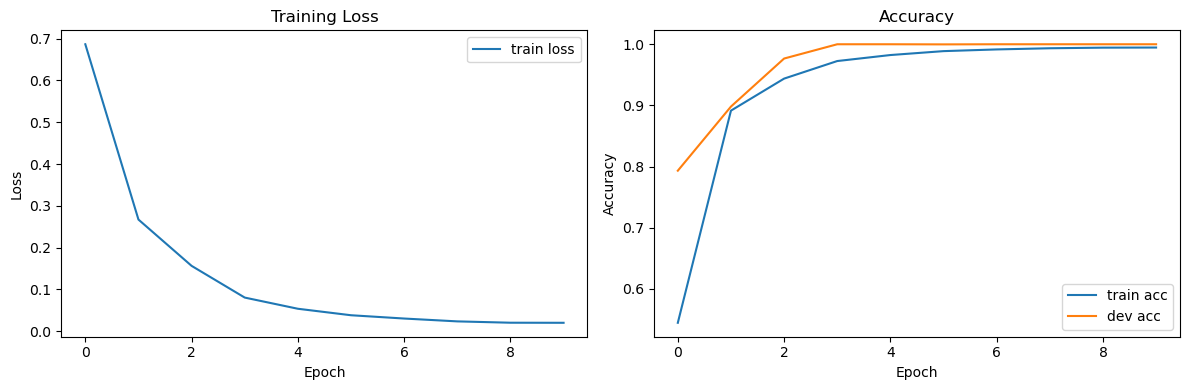

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_loss_curve, label="train loss")
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(train_acc_curve, label="train acc")
ax2.plot(dev_acc_curve, label="dev acc")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()

os.makedirs("../results/figures", exist_ok=True)

plt.tight_layout()
plt.savefig("../results/figures/det_training_curves.pdf")
plt.show()